# LRK10L ML model

## Setup

### Imports & installations

In [142]:
%load_ext autoreload
%autoreload 2

import math
import os
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from scipy.stats import friedmanchisquare, studentized_range
import scikit_posthocs as sp

import pyhmmer
from Bio import SeqIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord

from xgboost import XGBClassifier
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import precision_score, recall_score, accuracy_score, average_precision_score, precision_recall_curve, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

from lrk10l.evaluation import LOGOEvaluator
from lrk10l.pu import PUFilterMixin

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load data

In [143]:
dupe_genes = pd.read_csv('../saves/duplicate_genes.csv')['gene']
df_esm = pd.read_csv('../saves/dataset_esm.csv')
df_kmer = pd.read_csv('../saves/dataset_kmer.csv')

print('Duplicated genes:', dupe_genes.shape)
display(dupe_genes.head())

print('ESM dataset:', df_esm.shape)
display(df_esm.head())

print('k-mer dataset:', df_kmer.shape)
display(df_kmer.head())

Duplicated genes: (51,)


0    VIT_216s0148g00260.1
1    VIT_200s0258g00040.1
2    VIT_216s0050g02720.1
3    VIT_216s0039g01200.1
4    VIT_216s0098g00120.1
Name: gene, dtype: str

ESM dataset: (8945, 644)


,species,gene,seq,label,esm_0,esm_1,esm_2,esm_3,esm_4,esm_5,...,esm_630,esm_631,esm_632,esm_633,esm_634,esm_635,esm_636,esm_637,esm_638,esm_639
0,Slycopersicum_796_ITAG5.0.protein_primaryTrans...,PRAM_24043.1.p1,WLCITTQTQKLNMKNLERRITLVIIIMFVHFTASLAIIGTDEIALL...,False,-0.108978,-0.073140,-0.096568,-0.203365,0.074926,-0.034012,...,-0.062629,0.111783,-0.145721,0.036615,-0.052408,0.011184,-0.168351,0.034375,-0.175060,0.098445
1,Slycopersicum_796_ITAG5.0.protein_primaryTrans...,PRAM_25906.1.p1,MLRKTCKMNLEFVCLLLLLSWLKVLDHSIAATSLAKPGCEERCGNL...,False,-0.051743,-0.003080,-0.001061,-0.078826,0.004703,-0.019327,...,-0.056906,0.069938,-0.224253,-0.004619,-0.055436,0.126528,-0.120996,0.078235,-0.106939,0.048921
2,Slycopersicum_796_ITAG5.0.protein_primaryTrans...,PRAM_26245.1.p1,MLSDLHTTVILFVILCYLDMPISLGQDDEQYRSCGEPFRCGSMDIV...,True,-0.059590,-0.007336,-0.021861,-0.109931,0.001727,-0.035662,...,-0.077579,0.078597,-0.175661,-0.010940,-0.073713,0.105934,-0.174750,0.059239,-0.104596,0.074747
3,Slycopersicum_796_ITAG5.0.protein_primaryTrans...,PRAM_26268.1.p1,MASGSIMSSAAGKPITDVVLIDNLPKEINAMKINDDKEGKEMEAAV...,False,-0.135528,0.037328,0.073279,-0.121510,-0.060559,-0.052883,...,-0.075612,0.008499,-0.089771,-0.053778,-0.137369,0.010480,-0.045366,0.040035,-0.264432,-0.065106
4,Slycopersicum_796_ITAG5.0.protein_primaryTrans...,PRAM_26328.1.p1,MFLDSNELKMNYSHLIFVFTIILAYSSVSILAQQPYFGTGTNDCSS...,False,-0.057697,-0.019242,-0.091726,-0.091741,-0.047440,-0.013892,...,-0.063160,0.084078,-0.114984,-0.043391,-0.125841,0.114626,-0.098426,0.043996,-0.099936,0.082743


k-mer dataset: (8945, 404)


,species,gene,seq,label,kmer_AA,kmer_AC,kmer_AD,kmer_AE,kmer_AF,kmer_AG,...,kmer_YM,kmer_YN,kmer_YP,kmer_YQ,kmer_YR,kmer_YS,kmer_YT,kmer_YV,kmer_YW,kmer_YY
0,Slycopersicum_796_ITAG5.0.protein_primaryTrans...,PRAM_24043.1.p1,WLCITTQTQKLNMKNLERRITLVIIIMFVHFTASLAIIGTDEIALL...,False,0.001820,0.000910,0.000000,0.001820,0.000910,0.000000,...,0.000910,0.00182,0.000910,0.000000,0.000000,0.001820,0.000000,0.000910,0.0,0.000910
1,Slycopersicum_796_ITAG5.0.protein_primaryTrans...,PRAM_25906.1.p1,MLRKTCKMNLEFVCLLLLLSWLKVLDHSIAATSLAKPGCEERCGNL...,False,0.007072,0.000000,0.000000,0.002829,0.000000,0.002829,...,0.001414,0.00000,0.002829,0.000000,0.002829,0.002829,0.002829,0.001414,0.0,0.001414
2,Slycopersicum_796_ITAG5.0.protein_primaryTrans...,PRAM_26245.1.p1,MLSDLHTTVILFVILCYLDMPISLGQDDEQYRSCGEPFRCGSMDIV...,True,0.003049,0.000000,0.000000,0.000000,0.001524,0.003049,...,0.000000,0.00000,0.001524,0.003049,0.001524,0.006098,0.001524,0.003049,0.0,0.000000
3,Slycopersicum_796_ITAG5.0.protein_primaryTrans...,PRAM_26268.1.p1,MASGSIMSSAAGKPITDVVLIDNLPKEINAMKINDDKEGKEMEAAV...,False,0.004890,0.000000,0.000000,0.004890,0.002445,0.002445,...,0.002445,0.00000,0.000000,0.002445,0.004890,0.004890,0.007335,0.002445,0.0,0.002445
4,Slycopersicum_796_ITAG5.0.protein_primaryTrans...,PRAM_26328.1.p1,MFLDSNELKMNYSHLIFVFTIILAYSSVSILAQQPYFGTGTNDCSS...,False,0.006126,0.001531,0.003063,0.003063,0.003063,0.003063,...,0.001531,0.00000,0.001531,0.001531,0.001531,0.003063,0.001531,0.003063,0.0,0.000000


### Helper functions

In [144]:
def clean_gene_id(gene_id: str) -> str:
    return gene_id.split('|')[0]

def get_scale_pos_weight(y):
    return (y == 0).sum() / (y == 1).sum()

## Leave-one-group-out

In [145]:
logo = LeaveOneGroupOut()

## HMM baseline

Three-way outer split by species: use N-2 species to build the HMM, one validation species to select the e-value threshold, and one test species for final metrics.

In [146]:
LOAD_HMM_RESULTS = True  #@param {"type": "boolean"}

### Align, build, scan

In [147]:
hmm_baseline_dir = '../intermediate/hmm_baseline'
hmm_results_name = '../saves/hmm_results_df.csv'
os.makedirs(hmm_baseline_dir, exist_ok=True)

In [148]:
if not LOAD_HMM_RESULTS:
    dupe_gene_set = set(dupe_genes)

    hmm_df_full = df_kmer[['gene', 'species', 'label']].astype({'label': int})
    hmm_df_full['record'] = [
        SeqRecord(Seq(row.seq), id=row.gene, description='')
        for row in df_kmer.itertuples()
    ]

    hmm_df = hmm_df_full[~hmm_df_full['gene'].isin(dupe_gene_set)]
    labels = hmm_df_full.set_index('gene')['label']

    hmm_results = []
    all_species = sorted(hmm_df['species'].unique())

    def get_validation_species(all_species, test_species):
        others = [species for species in all_species if species != test_species]
        index = all_species.index(test_species) % len(others)
        return others[index]

    pbar = tqdm(all_species, desc='Evaluate HMM')
    for test_species in pbar:
        validation_species = get_validation_species(all_species, test_species)
        train_species = [
            species for species in all_species
            if species not in {validation_species, test_species}
        ]

        train_df = hmm_df[hmm_df['species'].isin(train_species)]
        validation_df = hmm_df[hmm_df['species'] == validation_species]
        test_df = hmm_df_full[hmm_df_full['species'] == test_species]

        species_pretty = test_species.split('_')[0]
        validation_species_pretty = validation_species.split('_')[0]
        pbar.set_postfix_str(species_pretty)

        train_fa_name = f'{hmm_baseline_dir}/{species_pretty}_train.fasta'
        validation_fa_name = f'{hmm_baseline_dir}/{species_pretty}_validation.fasta'
        test_fa_name = f'{hmm_baseline_dir}/{species_pretty}_test.fasta'
        aligned_fa_name = f'{hmm_baseline_dir}/{species_pretty}_train_aligned.fasta'

        SeqIO.write(
            list(train_df[train_df['label'] == 1]['record']),
            train_fa_name,
            'fasta',
        )
        SeqIO.write(list(validation_df['record']), validation_fa_name, 'fasta')
        SeqIO.write(list(test_df['record']), test_fa_name, 'fasta')

        !muscle -align {train_fa_name} -output {aligned_fa_name} -quiet

        alphabet = pyhmmer.easel.Alphabet.amino()
        with pyhmmer.easel.MSAFile(aligned_fa_name, digital=True, alphabet=alphabet) as msa_file:
            msa = msa_file.read()
            msa.name = f'LRK10L_{species_pretty}'

            builder = pyhmmer.plan7.Builder(alphabet)
            background = pyhmmer.plan7.Background(alphabet)
            hmm, _, _ = builder.build_msa(msa, background)

        for split_name, split_species, split_fa_name, split_df in [
            ('validation', validation_species, validation_fa_name, validation_df),
            ('test', test_species, test_fa_name, test_df),
        ]:
            with pyhmmer.easel.SequenceFile(split_fa_name, digital=True, alphabet=alphabet) as seq_file:
                split_seqs = list(seq_file)

            for seq, hits in zip(split_seqs, pyhmmer.hmmscan(split_seqs, [hmm], E=1e-4)):
                best_hit = min(hits, key=lambda h: h.evalue, default=None)
                hmm_results.append({
                    'outer_test_species': test_species,
                    'validation_species': validation_species,
                    'species': split_species,
                    'split': split_name,
                    'record_id': seq.name,
                    'pred_label': 1 if best_hit is not None else 0,
                    'true_label': labels[seq.name],
                    'evalue': best_hit.evalue if best_hit is not None else None,
                })

    hmm_results_df = pd.DataFrame(hmm_results)
    hmm_results_df.to_csv(hmm_results_name, index=False)
else:
    hmm_results_df = pd.read_csv(hmm_results_name)

### Visualize log e-values by label

,count,mean,std,min,25%,50%,75%,max
true_label,,,,,,,,
0,17030.0,1.648742e-08,9.505046e-07,0.0,4.275000e-101,1.354077e-77,1.087971e-36,8.384228e-05
1,667.0,5.368517e-30,1.322094e-28,0.0,3.386183e-203,1.305629e-178,1.313547e-156,3.410490e-27


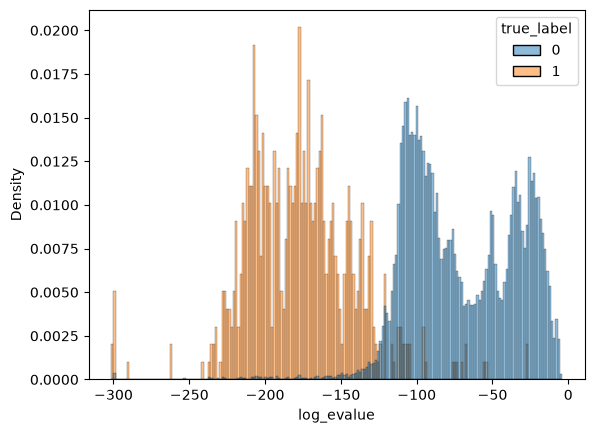

In [149]:
hmm_results_df['log_evalue'] = np.log10(hmm_results_df['evalue'].replace(0, 1e-300))

sns.histplot(data=hmm_results_df, x='log_evalue', hue='true_label', bins=200, stat='density', common_norm=False)
hmm_results_df.groupby('true_label')['evalue'].describe()

### Generate metrics

In [150]:
hmm_results_df['evalue_filled'] = hmm_results_df['evalue'].fillna(1e10)


def best_f1_evalue_threshold(y_true, evalues):
    candidates = np.unique(evalues)
    best_threshold, best_f1 = float(candidates[0]), -1.0
    for threshold in candidates:
        f1 = f1_score(y_true, evalues <= threshold, zero_division=0)
        if f1 > best_f1:
            best_threshold, best_f1 = float(threshold), float(f1)
    return best_threshold, best_f1


all_test_species = sorted(hmm_results_df['outer_test_species'].unique())
hmm_fold_rows = []
hmm_fold_preds = {}

for test_species in all_test_species:
    fold_rows = hmm_results_df[hmm_results_df['outer_test_species'] == test_species]
    validation_rows = fold_rows[fold_rows['split'] == 'validation']
    test_rows = fold_rows[fold_rows['split'] == 'test']

    validation_threshold, validation_f1 = best_f1_evalue_threshold(
        validation_rows['true_label'].to_numpy(),
        validation_rows['evalue_filled'].to_numpy(),
    )
    test_y = test_rows['true_label'].to_numpy()
    test_evalues = test_rows['evalue_filled'].to_numpy()
    test_pred = test_evalues <= validation_threshold

    hmm_results_df.loc[fold_rows.index, 'fold_threshold'] = validation_threshold
    hmm_results_df.loc[fold_rows.index, 'pred_label'] = (
        hmm_results_df.loc[fold_rows.index, 'evalue_filled'] <= validation_threshold
    ).astype(int)
    hmm_fold_preds[test_species] = {
        'y_true': test_y,
        'preds': -test_evalues,
    }

    hmm_fold_rows.append({
        'species': test_species.split('_')[0],
        'validation_species': validation_rows['species'].iloc[0].split('_')[0],
        'threshold': validation_threshold,
        'val_f1_at_threshold': validation_f1,
        'test_pr_auc': average_precision_score(test_y, -test_evalues),
        'test_precision': precision_score(test_y, test_pred, zero_division=0),
        'test_recall': recall_score(test_y, test_pred, zero_division=0),
        'test_accuracy': accuracy_score(test_y, test_pred),
        'n_pos': int(test_y.sum()),
        'found': int(((test_y == 1) & test_pred).sum()),
        'false_positives': int(((test_y == 0) & test_pred).sum()),
    })

hmm_fold_results = pd.DataFrame(hmm_fold_rows)

In [151]:
hmm_fold_results = hmm_fold_results.assign(
    precision=hmm_fold_results['test_precision'],
    recall=hmm_fold_results['test_recall'],
    accuracy=hmm_fold_results['test_accuracy'],
)

hmm_fold_results[[
    'species', 'validation_species', 'threshold', 'val_f1_at_threshold',
    'test_pr_auc', 'test_precision', 'test_recall', 'test_accuracy',
    'n_pos', 'found', 'false_positives'
]]

,species,validation_species,threshold,val_f1_at_threshold,test_pr_auc,test_precision,test_recall,test_accuracy,n_pos,found,false_positives
0,Athaliana,Fvesca,1.126523e-121,0.454545,0.925902,0.406250,1.000000,0.981281,13,13,19
1,Fvesca,Gmax,1.235060e-140,0.869565,0.360404,0.250000,0.400000,0.980519,10,4,12
2,Gmax,Osativa,1.237162e-135,0.895238,0.920758,0.876404,0.866667,0.989583,90,78,11
3,Osativa,Pvulgaris,5.732082e-140,0.948905,0.848862,0.860000,0.826923,0.988850,52,43,7
4,Pvulgaris,Slycopersicum,1.248097e-207,0.486486,0.957323,1.000000,0.246575,0.955029,73,18,0
5,Slycopersicum,Vvinifera,1.054984e-151,0.787879,0.337653,0.304348,0.823529,0.963466,17,14,32
6,Vvinifera,Athaliana,9.092581e-168,0.916667,0.680681,0.746988,0.596154,0.946701,104,62,21


### Keep embeddings for full data

## [XGB] Model

### XGBoost model

In [152]:
def make_model(scale_pos_weight, random_state=2026):
    return XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        eval_metric=['aucpr'],

        n_estimators=1200,
        max_depth=3,
        learning_rate=0.05,
        min_child_weight=6,
        gamma=0,

        random_state=random_state,
        n_jobs=-1,
    )

class XGBEvaluator(PUFilterMixin, LOGOEvaluator):
    def make_model_per_split(self, X_train, y_train):
        scale_pos_weight = get_scale_pos_weight(y_train)
        return make_model(scale_pos_weight)

    def fit_model_per_split(self, model, X_train, y_train, X_val, y_val, X_test, y_test):
        model.fit(
            X_train, y_train,
            eval_set=[(X_train, y_train), (X_test, y_test)],
            verbose=False,
        )
        return model

    def extra_metrics_per_split(self, model, X_train, y_train, X_test, y_test):
        evals = model.evals_result()
        val_curve = evals['validation_1']['aucpr']
        best_round = int(np.argmax(val_curve))
        return {
            'best_round': best_round,
            'best_val_pr_auc': val_curve[best_round],
            'final_val_pr_auc': val_curve[-1],
            'n_flagged': getattr(self, '_last_n_flagged', None),
        }

    def extra_artifacts_per_split(self, model, X_train, y_train, X_test, y_test, 
                                  X_test_full, y_test_full, preds_full):
        artifacts = {
            'evals': model.evals_result(),
            'importance': pd.Series(
                model.feature_importances_, index=X_train.columns
            ).sort_values(ascending=False),
        }
        return artifacts

### Fit

In [153]:
# Fit XGBoost with k-mer
xgb_evaluator = XGBEvaluator.from_gene_dataset(
    logo, df_kmer,
    dupe_genes=dupe_genes,
    auto_threshold=True,
    run_pu=True,
)
xgb_evaluator.fit()

xgb_results = xgb_evaluator.results_df[[
    'species', 'validation_species', 'threshold', 'val_f1_at_threshold',
    'test_pr_auc', 'test_precision', 'test_recall', 'n_pos', 'found',
    'false_positives'
]]
xgb_results

Evaluating: 100%|██████████| 7/7 [01:22<00:00, 11.74s/it, Vvinifera]    


,species,validation_species,threshold,val_f1_at_threshold,test_pr_auc,test_precision,test_recall,n_pos,found,false_positives
Athaliana_447_Araport11.protein_primaryTranscriptOnly,Athaliana,Fvesca,0.532190,0.823529,0.808476,0.777778,0.538462,13,7,2
Fvesca_226_v1.1.protein_primaryTranscriptOnly,Fvesca,Gmax,0.185875,0.887417,0.714703,0.538462,0.700000,10,7,6
Gmax_189_protein_primaryTranscriptOnly,Gmax,Osativa,0.141321,0.804124,0.932498,0.846154,0.868421,90,78,12
Osativa_204_v7.0.protein_primaryTranscriptOnly,Osativa,Pvulgaris,0.659826,0.962406,0.891862,0.970588,0.647059,52,34,1
Pvulgaris_442_v2.1.protein_primaryTranscriptOnly,Pvulgaris,Slycopersicum,0.154326,0.714286,0.978118,0.904110,0.970588,73,71,7
Slycopersicum_796_ITAG5.0.protein_primaryTranscriptOnly,Slycopersicum,Vvinifera,0.561533,0.887417,0.665361,0.526316,0.588235,17,10,9
Vvinifera_457_v2.1.protein_primaryTranscriptOnly,Vvinifera,Athaliana,0.785321,0.782609,0.925479,0.871429,0.835616,104,91,9


In [154]:
test_precision = xgb_evaluator.results_df['test_precision']
test_recall = xgb_evaluator.results_df['test_recall']

print("XGB model (held-out test species)")
print(f"Test precision: {test_precision.mean():.3f}±{test_precision.std():.3f}")
print(f"Test recall:    {test_recall.mean():.3f}±{test_recall.std():.3f}")

XGB model (held-out test species)
Test precision: 0.776±0.177
Test recall:    0.735±0.159


### Learning curves

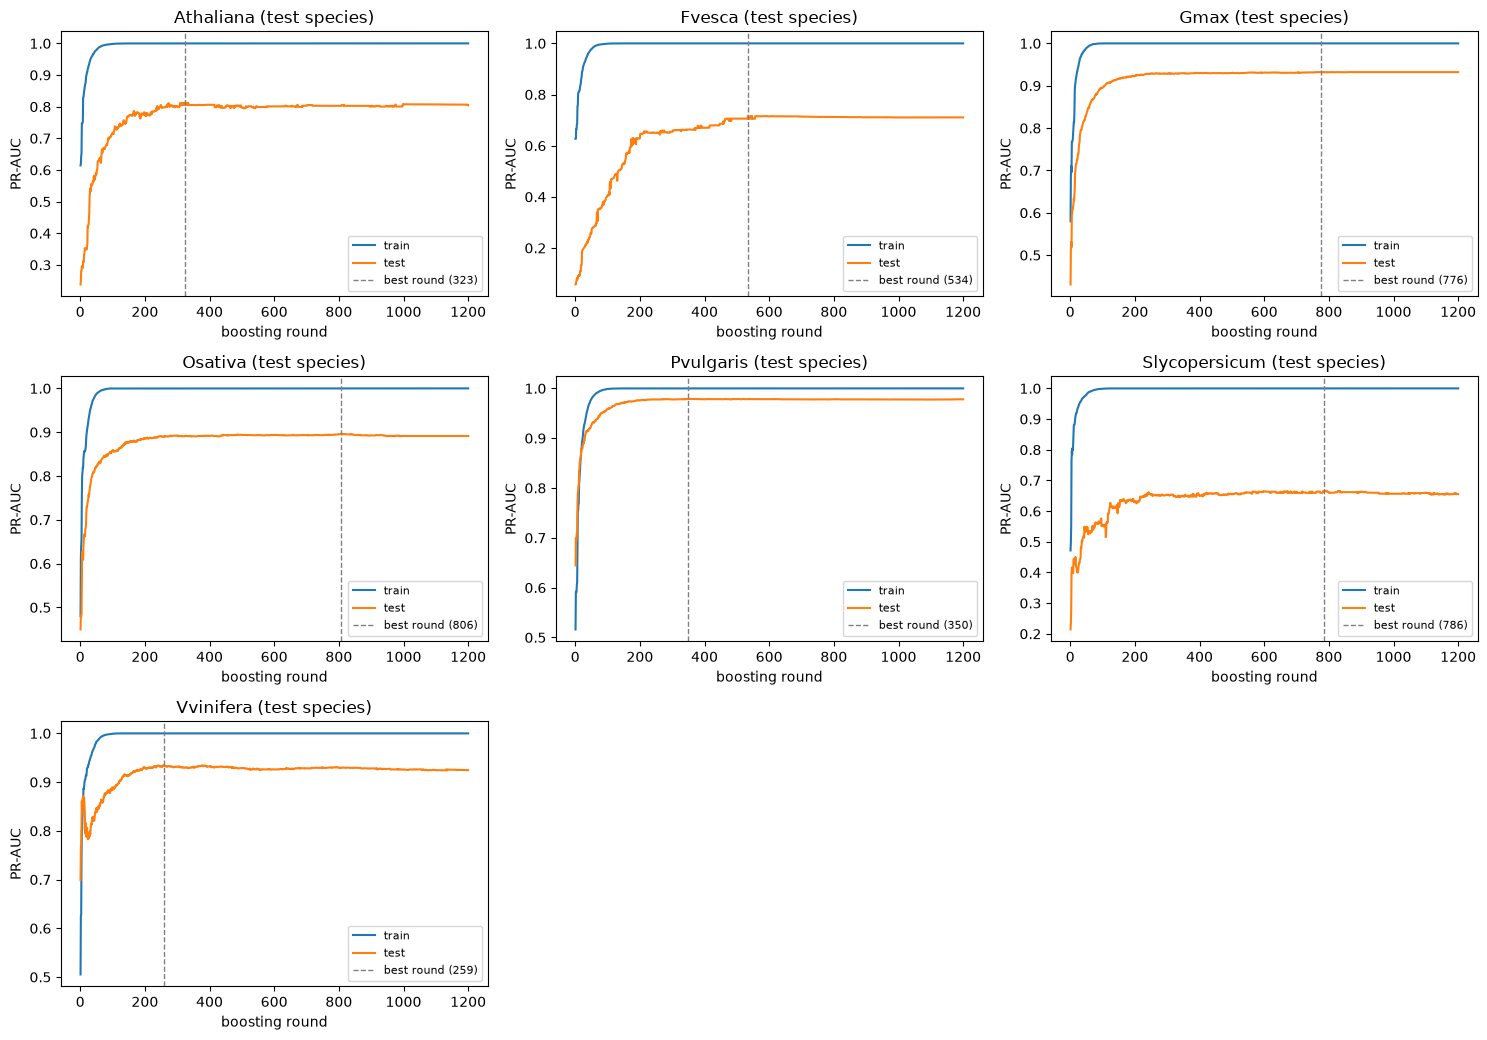

In [155]:
species_list = list(xgb_evaluator.fold_artifacts.keys())
n = len(species_list)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows), squeeze=False)

for i, species in enumerate(species_list):
    ax = axes[i // ncols][i % ncols]
    evals = xgb_evaluator.fold_artifacts[species]['evals']
    train_curve = evals['validation_0']['aucpr']
    test_curve = evals['validation_1']['aucpr']
    rounds = range(1, len(train_curve) + 1)

    ax.plot(rounds, train_curve, label='train', color='tab:blue')
    ax.plot(rounds, test_curve, label='test', color='tab:orange')
    best_round = int(xgb_evaluator.fold_results[species]['best_round']) + 1
    ax.axvline(best_round, color='gray', linestyle='--', linewidth=1, label=f'best round ({best_round})')
    ax.set_title(f'{species.split("_")[0]} (test species)')
    ax.set_xlabel('boosting round')
    ax.set_ylabel('PR-AUC')
    ax.legend(fontsize=8)

for j in range(n, nrows * ncols):
    axes[j // ncols][j % ncols].axis('off')

plt.tight_layout()
plt.show()

### Precision-recall graphs

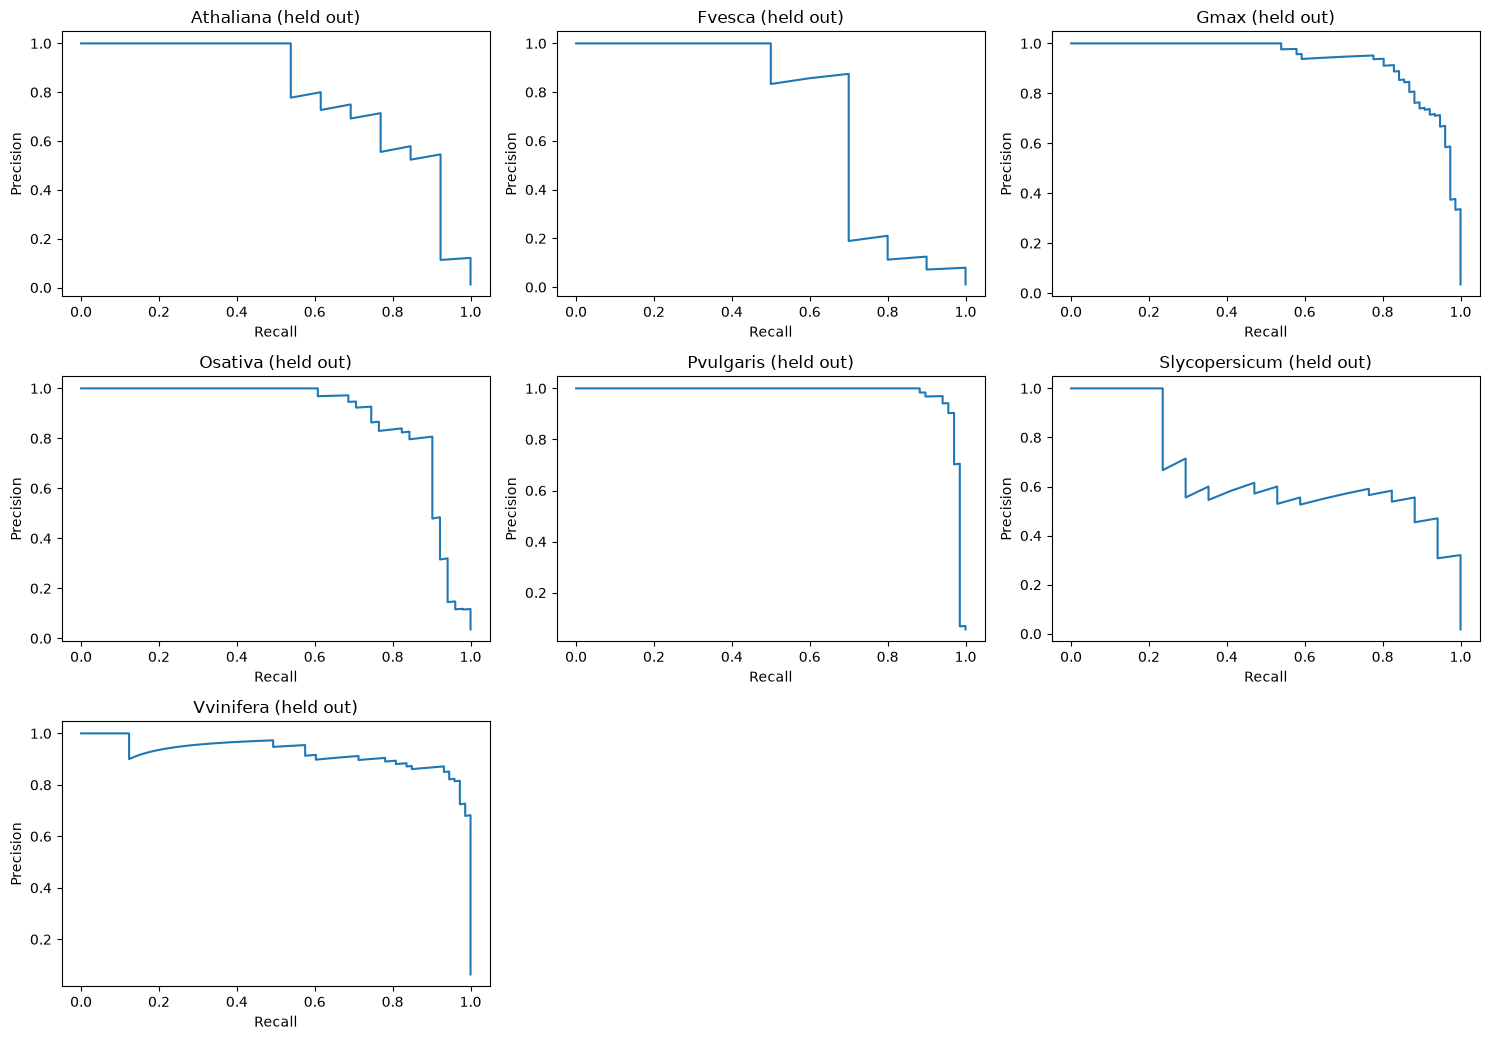

In [156]:
species_list = list(xgb_evaluator.fold_preds.keys())
n = len(species_list)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows), squeeze=False)

for i, species in enumerate(species_list):
    ax = axes[i // ncols][i % ncols]
    data = xgb_evaluator.fold_preds[species]
    precisions, recalls, thresholds = precision_recall_curve(data['y_true'], data['preds'])

    ax.plot(recalls, precisions, color='tab:blue')
    ax.set_title(f'{species.split("_")[0]} (held out)')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')

for j in range(n, nrows * ncols):
    axes[j // ncols][j % ncols].axis('off')

plt.tight_layout()
plt.show()

### Precision-recall aggregated

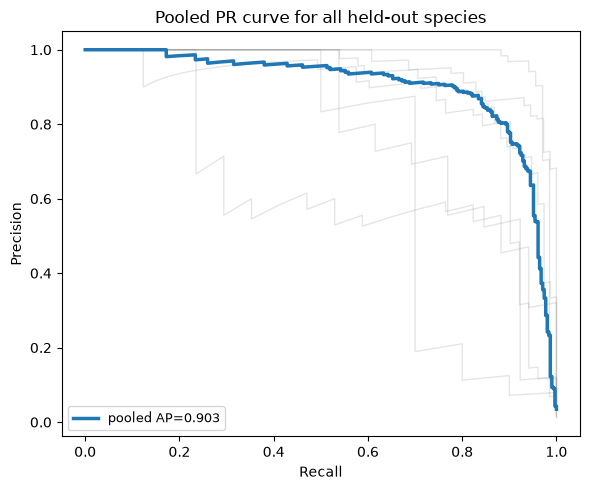

In [157]:
all_y_true = np.concatenate([xgb_evaluator.fold_preds[s]['y_true'] for s in xgb_evaluator.fold_preds])
all_preds = np.concatenate([xgb_evaluator.fold_preds[s]['preds'] for s in xgb_evaluator.fold_preds])

precisions_xgb, recalls_xgb, thresholds_xgb = precision_recall_curve(all_y_true, all_preds)
pr_auc = average_precision_score(all_y_true, all_preds)

fig, ax = plt.subplots(figsize=(6, 5))

for species, data in xgb_evaluator.fold_preds.items():
    p, r, _ = precision_recall_curve(data['y_true'], data['preds'])
    ax.plot(r, p, color='gray', alpha=0.2, linewidth=1)

ax.plot(recalls_xgb, precisions_xgb, color='tab:blue', linewidth=2.5, label=f'pooled AP={pr_auc:.3f}')

ax.set_title('Pooled PR curve for all held-out species')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### Recall at FP budgets

In [158]:
def recall_at_fp_budgets(y_true, preds, fp_budgets):
    order = np.argsort(-preds)
    y_sorted = y_true[order]

    n_pos = y_sorted.sum()
    cum_tp = np.cumsum(y_sorted == 1)
    cum_fp = np.cumsum(y_sorted == 0)

    results = {}
    for budget in fp_budgets:
        eligible = np.where(cum_fp <= budget)[0]
        if len(eligible) == 0:
            results[budget] = {'found': 0, 'recall': 0.0, 'actual_fp': 0}
            continue
        idx = eligible[-1]
        results[budget] = {
            'found': int(cum_tp[idx]),
            'recall': cum_tp[idx] / n_pos,
            'actual_fp': int(cum_fp[idx]),
        }
    return results

fp_budgets = [5, 10, 15]

recall_rows = {}
for species, data in xgb_evaluator.fold_preds.items():
    per_budget = recall_at_fp_budgets(data['y_true'], data['preds'], fp_budgets)
    for budget, stats in per_budget.items():
        recall_rows[(species.split('_')[0], budget)] = stats

recall_df = pd.DataFrame(recall_rows).T
recall_df.index.names = ['species', 'fp_budget']
recall_df

found    recall  actual_fp
species       fp_budget                            
Athaliana     5           10.0  0.769231        5.0
              10          12.0  0.923077       10.0
              15          12.0  0.923077       15.0
Fvesca        5            7.0  0.700000        5.0
              10           7.0  0.700000       10.0
              15           7.0  0.700000       15.0
Gmax          5           61.0  0.802632        5.0
              10          64.0  0.842105       10.0
              15          66.0  0.868421       15.0
Osativa       5           38.0  0.745098        5.0
              10          43.0  0.843137       10.0
              15          46.0  0.901961       15.0
Pvulgaris     5           65.0  0.955882        5.0
              10          66.0  0.970588       10.0
              15          66.0  0.970588       15.0
Slycopersicum 5            8.0  0.470588        5.0
              10          14.0  0.823529       10.0
              15          15.0  0.882353       15.0
Vvinifera     5           52.0  0.712329        5.0
              10          68.0  0.931507       10.0
              15          70.0  0.958904       15.0

### Species-specific split details

In [159]:
def specific_results(species_full: str):
    species_short = species_full.split('_')[0]
    df = xgb_evaluator.fold_details[species_full]
    threshold = xgb_evaluator.fold_results[species_full]['threshold']

    predicted_positive = df['pred'] >= threshold
    hits = df[(df['y_true'] == 1) & predicted_positive]
    misses = df[(df['y_true'] == 1) & ~predicted_positive]
    false_positives = df[(df['y_true'] == 0) & predicted_positive]

    print(f"\n{'='*10} {species_short} (test species; threshold={threshold:.3f}) {'='*10}")
    print(f'Hits ({len(hits)}):\n{hits}')
    print(f'\nMisses ({len(misses)}):\n{misses}')
    print(f'\nFalse positives ({len(false_positives)}):\n{false_positives}')

specific_results('Slycopersicum_796_ITAG5.0.protein_primaryTranscriptOnly')
specific_results('Athaliana_447_Araport11.protein_primaryTranscriptOnly')
specific_results('Osativa_204_v7.0.protein_primaryTranscriptOnly')
specific_results('Vvinifera_457_v2.1.protein_primaryTranscriptOnly')
specific_results('Gmax_189_protein_primaryTranscriptOnly')
specific_results('Fvesca_226_v1.1.protein_primaryTranscriptOnly')
specific_results('Pvulgaris_442_v2.1.protein_primaryTranscriptOnly')


========== Slycopersicum (test species; threshold=0.562) ==========
Hits (10):
                  id  y_true      pred
0   Solyc04T000158.1       1  0.999826
1   Solyc05T000401.1       1  0.999790
2   Solyc03T000226.2       1  0.999620
3   Solyc03T001769.1       1  0.999126
6    PRAM_26245.1.p1       1  0.996485
9   Solyc05T000399.1       1  0.991484
11  Solyc02T002539.1       1  0.987322
12  Solyc04T002734.1       1  0.970633
14  Solyc02T001806.1       1  0.962106
17  Solyc03T003214.1       1  0.697235

Misses (7):
                  id  y_true      pred
19  Solyc05T000396.1       1  0.470591
20  Solyc04T000159.1       1  0.302292
21  Solyc05T000406.1       1  0.281983
23  Solyc05T000582.1       1  0.209104
26  Solyc01T000282.1       1  0.143238
33  Solyc01T000276.1       1  0.026663
52  Solyc02T001670.1       1  0.006430

False positives (9):
                  id  y_true      pred
4   Solyc11T000232.1       0  0.998248
5   Solyc11T000233.1       0  0.997825
7   Solyc09T000267.1       

### Feature importance per split

#### Importance Spearman correlation

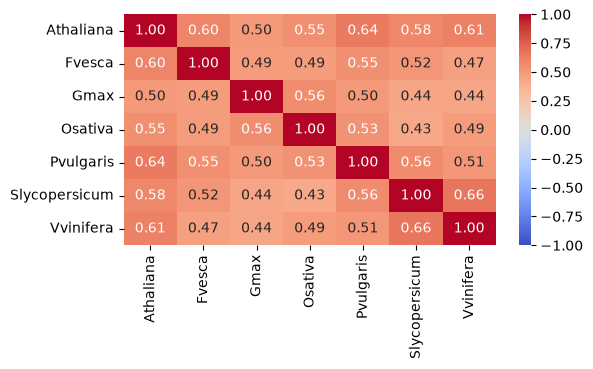

In [160]:
importance_df = pd.DataFrame({
    species.split('_')[0]: artifacts['importance']
    for species, artifacts in xgb_evaluator.fold_artifacts.items()
})

corr_matrix = importance_df.corr(method="spearman")
plt.figure(figsize=(6, 3))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.show()

#### Top features Jaccard similarity

In [161]:
def top_k_jaccard(importance_df, k=20):
    top_sets = {
        species: set(importance_df[species].sort_values(ascending=False).head(k).index)
        for species in importance_df.columns
    }

    species_list = list(top_sets.keys())
    results = {}
    for i in range(len(species_list)):
        for j in range(i+1, len(species_list)):
            a, b = species_list[i], species_list[j]
            intersection = top_sets[a] & top_sets[b]
            union = top_sets[a] | top_sets[b]
            results[(a, b)] = len(intersection) / len(union)

    return results, top_sets

jaccard_scores, top_sets = top_k_jaccard(importance_df, k=20)
for pair, score in jaccard_scores.items():
    print(f"{pair[0]} vs {pair[1]}: {score:.2f}")

common_across_all = set.intersection(*top_sets.values())
print(f"\n{len(common_across_all)} features in every fold's top-20:")
print(common_across_all)

Athaliana vs Fvesca: 0.29
Athaliana vs Gmax: 0.33
Athaliana vs Osativa: 0.33
Athaliana vs Pvulgaris: 0.33
Athaliana vs Slycopersicum: 0.38
Athaliana vs Vvinifera: 0.29
Fvesca vs Gmax: 0.38
Fvesca vs Osativa: 0.29
Fvesca vs Pvulgaris: 0.21
Fvesca vs Slycopersicum: 0.29
Fvesca vs Vvinifera: 0.29
Gmax vs Osativa: 0.33
Gmax vs Pvulgaris: 0.29
Gmax vs Slycopersicum: 0.21
Gmax vs Vvinifera: 0.25
Osativa vs Pvulgaris: 0.29
Osativa vs Slycopersicum: 0.33
Osativa vs Vvinifera: 0.33
Pvulgaris vs Slycopersicum: 0.25
Pvulgaris vs Vvinifera: 0.29
Slycopersicum vs Vvinifera: 0.43

6 features in every fold's top-20:
{'kmer_WC', 'kmer_GF', 'kmer_HF', 'kmer_DL', 'kmer_CG', 'kmer_GC'}


## [LogReg] Model

A simpler model than XGBoost, same purpose as cosine similarity above.

### Train model

In [162]:
class LogRegEvaluator(PUFilterMixin, LOGOEvaluator):
    def make_model_per_split(self, X_train, y_train):
        return make_pipeline(
            StandardScaler(),
            LogisticRegression(class_weight='balanced', max_iter=1000, random_state=2026, C=0.1)
        )

    def extra_metrics_per_split(self, model, X_train, y_train, X_test, y_test):
        return {'n_flagged': getattr(self, '_last_n_flagged', None)}

# Build logistic regression with ESM-2
logreg_evaluator = LogRegEvaluator.from_gene_dataset(
    logo, df_esm,
    dupe_genes=dupe_genes,
    auto_threshold=True,
    run_pu=True,
).fit()

logreg_results = logreg_evaluator.results_df[[
    'species', 'validation_species', 'threshold', 'val_f1_at_threshold',
    'test_pr_auc', 'test_precision', 'test_recall', 'n_pos', 'found',
    'false_positives'
]]
logreg_results

Evaluating: 100%|██████████| 7/7 [01:58<00:00, 16.97s/it, Vvinifera]    


,species,validation_species,threshold,val_f1_at_threshold,test_pr_auc,test_precision,test_recall,n_pos,found,false_positives
Athaliana_447_Araport11.protein_primaryTranscriptOnly,Athaliana,Fvesca,0.901834,0.888889,0.884343,0.600000,0.923077,13,12,8
Fvesca_226_v1.1.protein_primaryTranscriptOnly,Fvesca,Gmax,0.840798,0.902778,0.835926,1.000000,0.700000,10,7,0
Gmax_189_protein_primaryTranscriptOnly,Gmax,Osativa,0.941887,0.937500,0.947704,0.969231,0.828947,90,76,2
Osativa_204_v7.0.protein_primaryTranscriptOnly,Osativa,Pvulgaris,0.761227,0.970588,0.946126,0.957447,0.882353,52,46,2
Pvulgaris_442_v2.1.protein_primaryTranscriptOnly,Pvulgaris,Slycopersicum,0.942078,0.702703,0.973351,0.968254,0.897059,73,66,2
Slycopersicum_796_ITAG5.0.protein_primaryTranscriptOnly,Slycopersicum,Vvinifera,0.714895,0.862500,0.642995,0.538462,0.823529,17,14,12
Vvinifera_457_v2.1.protein_primaryTranscriptOnly,Vvinifera,Athaliana,0.998862,0.916667,0.814808,0.878049,0.493151,104,46,5


In [163]:
test_precision = logreg_evaluator.results_df['test_precision']
test_recall = logreg_evaluator.results_df['test_recall']

print("LogReg model (held-out test species)")
print(f"Test precision: {test_precision.mean():.3f}±{test_precision.std():.3f}")
print(f"Test recall:    {test_recall.mean():.3f}±{test_recall.std():.3f}")

LogReg model (held-out test species)
Test precision: 0.844±0.193
Test recall:    0.793±0.151


### Precision-recall graphs

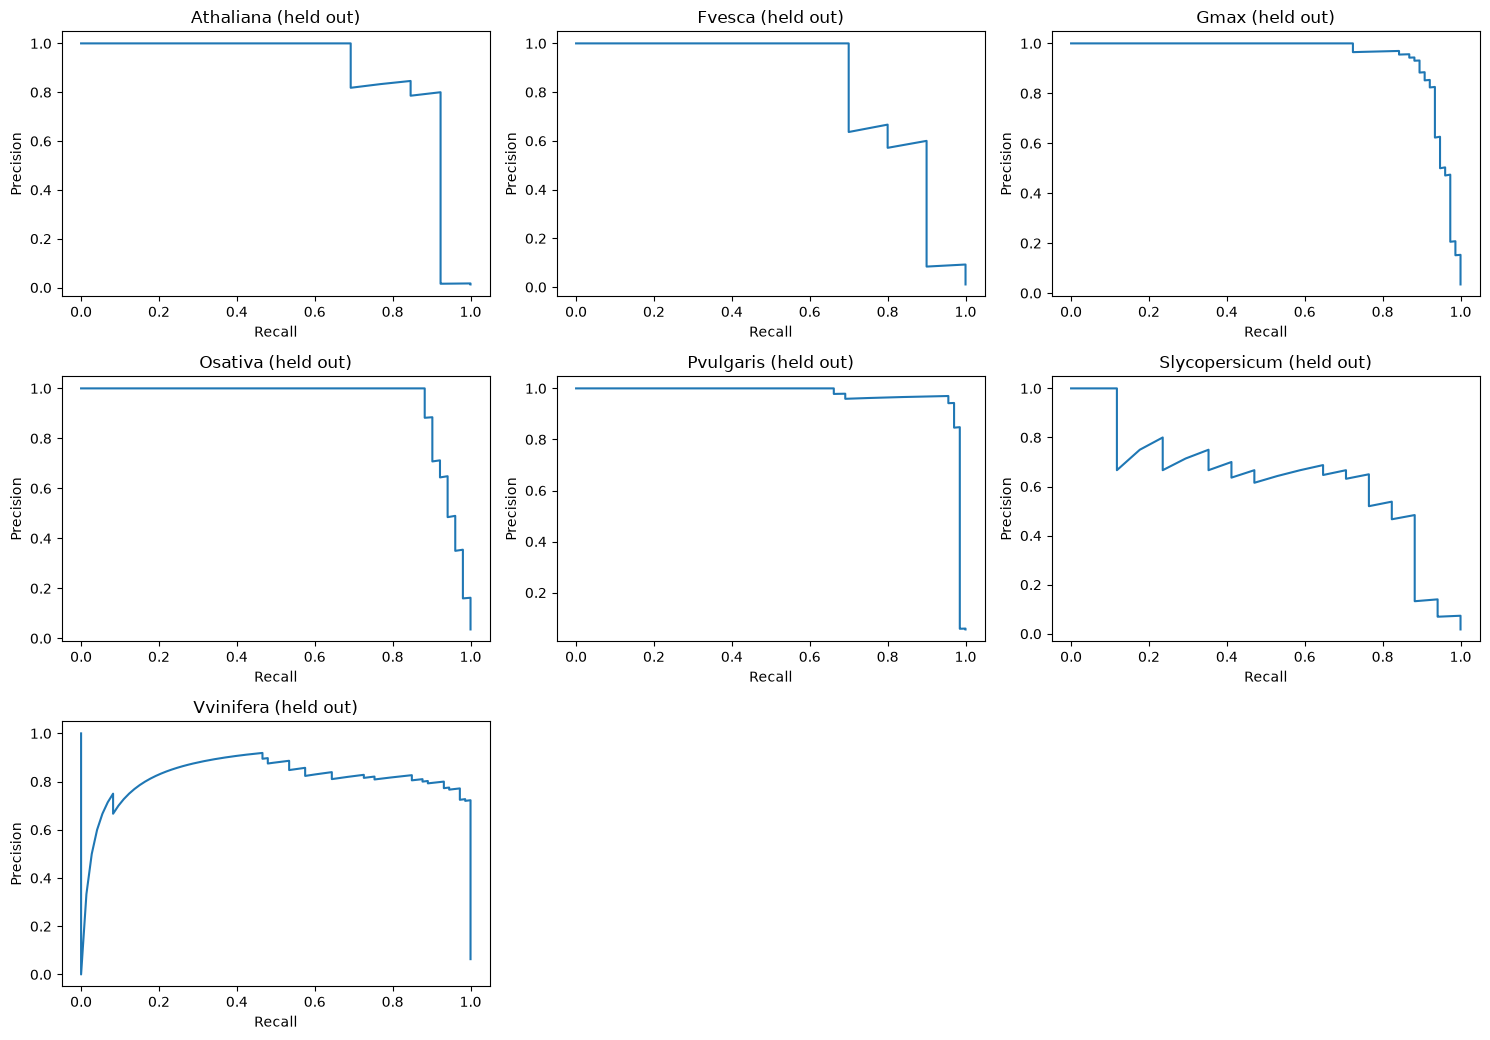

In [164]:
species_list = list(logreg_evaluator.fold_preds.keys())
n = len(species_list)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows), squeeze=False)

for i, species in enumerate(species_list):
    ax = axes[i // ncols][i % ncols]
    data = logreg_evaluator.fold_preds[species]
    precisions, recalls, thresholds = precision_recall_curve(data['y_true'], data['preds'])

    ax.plot(recalls, precisions, color='tab:blue')
    ax.set_title(f'{species.split("_")[0]} (held out)')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')

for j in range(n, nrows * ncols):
    axes[j // ncols][j % ncols].axis('off')

plt.tight_layout()
plt.show()

### Precision-recall aggregated

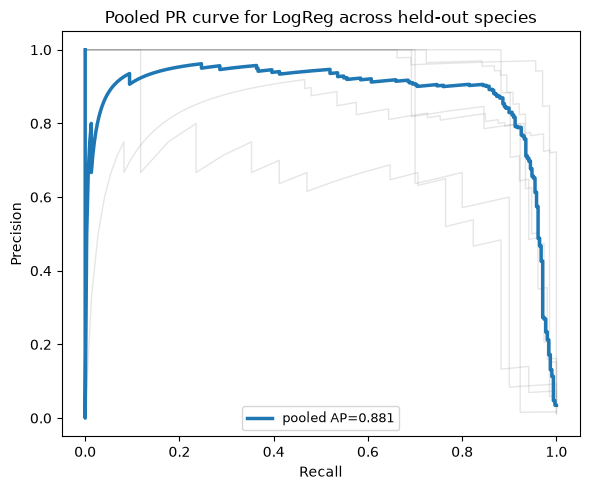

In [165]:
logreg_fold_preds = logreg_evaluator.fold_preds

all_y_true_logreg = np.concatenate([logreg_fold_preds[s]['y_true'] for s in logreg_fold_preds])
all_preds_logreg = np.concatenate([logreg_fold_preds[s]['preds'] for s in logreg_fold_preds])

precisions_logreg, recalls_logreg, thresholds_logreg = precision_recall_curve(all_y_true_logreg, all_preds_logreg)
pr_auc_logreg = average_precision_score(all_y_true_logreg, all_preds_logreg)

fig, ax = plt.subplots(figsize=(6, 5))

for species, data in logreg_fold_preds.items():
    p, r, _ = precision_recall_curve(data['y_true'], data['preds'])
    ax.plot(r, p, color='gray', alpha=0.2, linewidth=1)

ax.plot(
    recalls_logreg, precisions_logreg, color='tab:blue', linewidth=2.5,
    label=f'pooled AP={pr_auc_logreg:.3f}',
)

ax.set_title('Pooled PR curve for LogReg across held-out species')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Meta-model

Combine k-mer XGB and ESM LogReg

### Make meta dataset

In [166]:
xgb_all = pd.concat(xgb_evaluator.fold_details.values()).set_index('id')
lr_all = pd.concat(logreg_evaluator.fold_details.values()).set_index('id')

meta_df = pd.DataFrame({
    'xgb_pred': xgb_all['pred'],
    'lr_pred': lr_all['pred'],
    'y_true': xgb_all['y_true'],
}).dropna()

assert (meta_df['y_true'] == lr_all.loc[meta_df.index, 'y_true']).all(), 'label mismatch between models'

meta_df['diff'] = meta_df['xgb_pred'] - meta_df['lr_pred']
meta_df['abs_diff'] = meta_df['diff'].abs()
meta_df['mean_pred'] = (meta_df['xgb_pred'] + meta_df['lr_pred']) / 2

meta_df['xgb_logit'] = np.log(meta_df['xgb_pred'] / (1 - meta_df['xgb_pred']))
meta_df['lr_logit'] = np.log(meta_df['lr_pred'] / (1 - meta_df['lr_pred']))

species_lookup = df_kmer.set_index('gene')['species']
meta_df['species'] = species_lookup.reindex(meta_df.index)

assert meta_df['species'].notna().all(), "some ids couldn't be matched to a species"

X_meta = meta_df[['xgb_logit', 'lr_logit']]
y_meta = meta_df['y_true'].values
groups_meta = meta_df['species'].values

X_meta.head()

,xgb_logit,lr_logit
id,,
AT1G01140.3,-11.743855,-13.195426
AT1G01450.1,-6.441428,-5.046497
AT1G01540.2,-9.289852,-6.648737
AT1G01560.2,-7.797339,-7.527608
AT1G01740.2,-10.774050,-11.496101


### Fit

In [167]:
class MetaEvaluator(LOGOEvaluator):
    def make_model_per_split(self, X_train, y_train):
        return LogisticRegression(
            class_weight='balanced',
            max_iter=1000,
            random_state=2026,
            C=0.1,
        )

meta_evaluator = MetaEvaluator(
    logo=logo,
    X=X_meta,
    y=y_meta,
    groups=groups_meta,
    auto_threshold=True,
)
meta_evaluator.fit()
meta_results = meta_evaluator.results_df[[
    'species', 'validation_species', 'threshold', 'val_f1_at_threshold',
    'test_pr_auc', 'test_precision', 'test_recall', 'n_pos', 'found',
    'false_positives'
]]
meta_results

Evaluating: 100%|██████████| 7/7 [00:04<00:00,  1.47it/s, Vvinifera]    


,species,validation_species,threshold,val_f1_at_threshold,test_pr_auc,test_precision,test_recall,n_pos,found,false_positives
Athaliana_447_Araport11.protein_primaryTranscriptOnly,Athaliana,Fvesca,0.958030,0.823529,0.882359,0.750000,0.923077,13,12,4
Fvesca_226_v1.1.protein_primaryTranscriptOnly,Fvesca,Gmax,0.765863,0.935484,0.829866,0.666667,0.800000,10,8,4
Gmax_189_protein_primaryTranscriptOnly,Gmax,Osativa,0.874664,0.916667,0.967960,0.951220,0.866667,90,78,4
Osativa_204_v7.0.protein_primaryTranscriptOnly,Osativa,Pvulgaris,0.950603,0.965986,0.943086,1.000000,0.846154,52,44,0
Pvulgaris_442_v2.1.protein_primaryTranscriptOnly,Pvulgaris,Slycopersicum,0.904250,0.750000,0.982622,0.934211,0.972603,73,71,5
Slycopersicum_796_ITAG5.0.protein_primaryTranscriptOnly,Slycopersicum,Vvinifera,0.952014,0.923767,0.679976,0.619048,0.764706,17,13,8
Vvinifera_457_v2.1.protein_primaryTranscriptOnly,Vvinifera,Athaliana,0.983004,0.888889,0.950355,0.884956,0.961538,104,100,13


### Precision-recall graphs

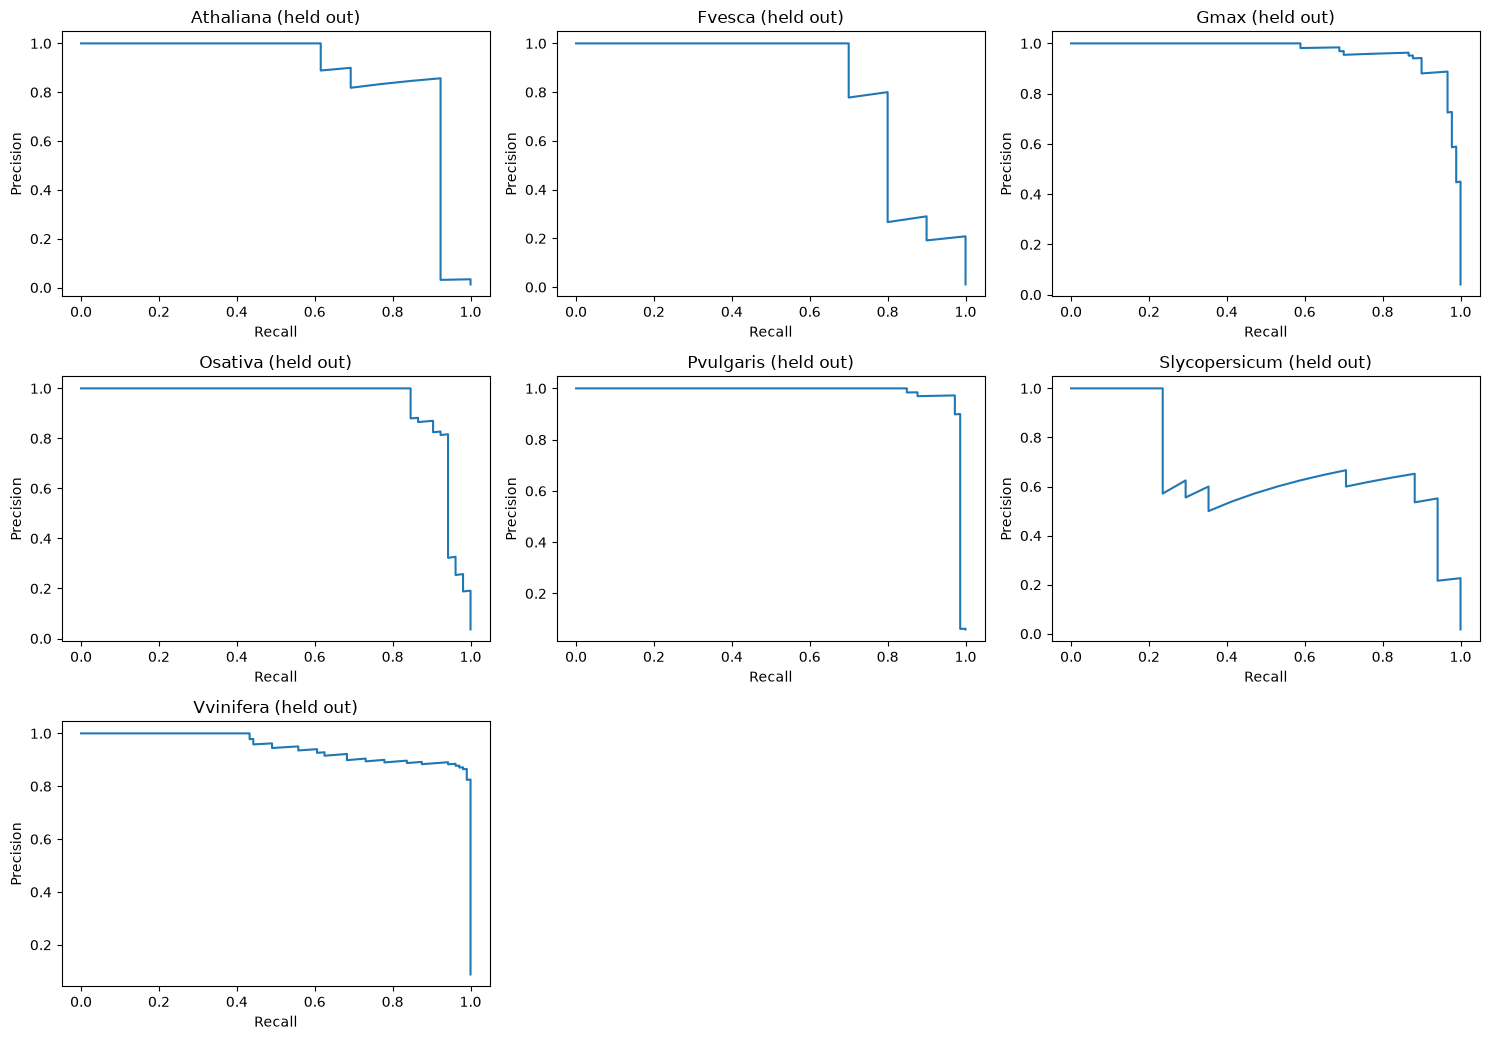

In [168]:
species_list = list(meta_evaluator.fold_preds.keys())
n = len(species_list)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows), squeeze=False)

for i, species in enumerate(species_list):
    ax = axes[i // ncols][i % ncols]
    data = meta_evaluator.fold_preds[species]
    precisions, recalls, thresholds = precision_recall_curve(data['y_true'], data['preds'])

    ax.plot(recalls, precisions, color='tab:blue')
    ax.set_title(f'{species.split("_")[0]} (held out)')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')

for j in range(n, nrows * ncols):
    axes[j // ncols][j % ncols].axis('off')

plt.tight_layout()
plt.show()

### Pooled PR curve

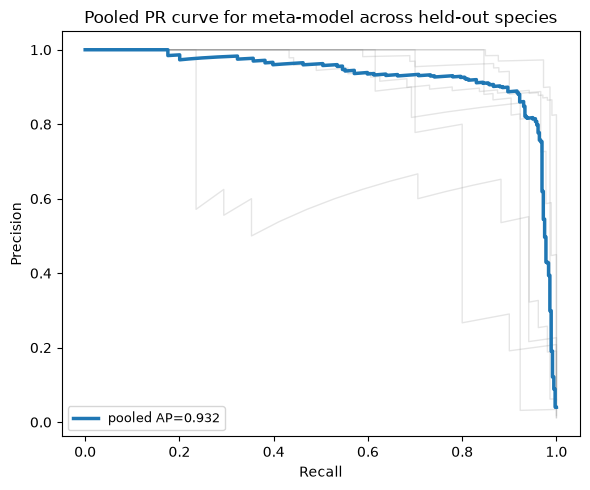

In [169]:
meta_fold_preds = meta_evaluator.fold_preds

all_y_true_meta = np.concatenate([meta_fold_preds[s]['y_true'] for s in meta_fold_preds])
all_preds_meta = np.concatenate([meta_fold_preds[s]['preds'] for s in meta_fold_preds])

precisions_meta, recalls_meta, thresholds_meta = precision_recall_curve(all_y_true_meta, all_preds_meta)
pr_auc_meta = average_precision_score(all_y_true_meta, all_preds_meta)

fig, ax = plt.subplots(figsize=(6, 5))

for species, data in meta_fold_preds.items():
    p, r, _ = precision_recall_curve(data['y_true'], data['preds'])
    ax.plot(r, p, color='gray', alpha=0.2, linewidth=1)

ax.plot(
    recalls_meta, precisions_meta, color='tab:blue', linewidth=2.5,
    label=f'pooled AP={pr_auc_meta:.3f}',
)

ax.set_title('Pooled PR curve for meta-model across held-out species')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Model comaprison

### Boxplots

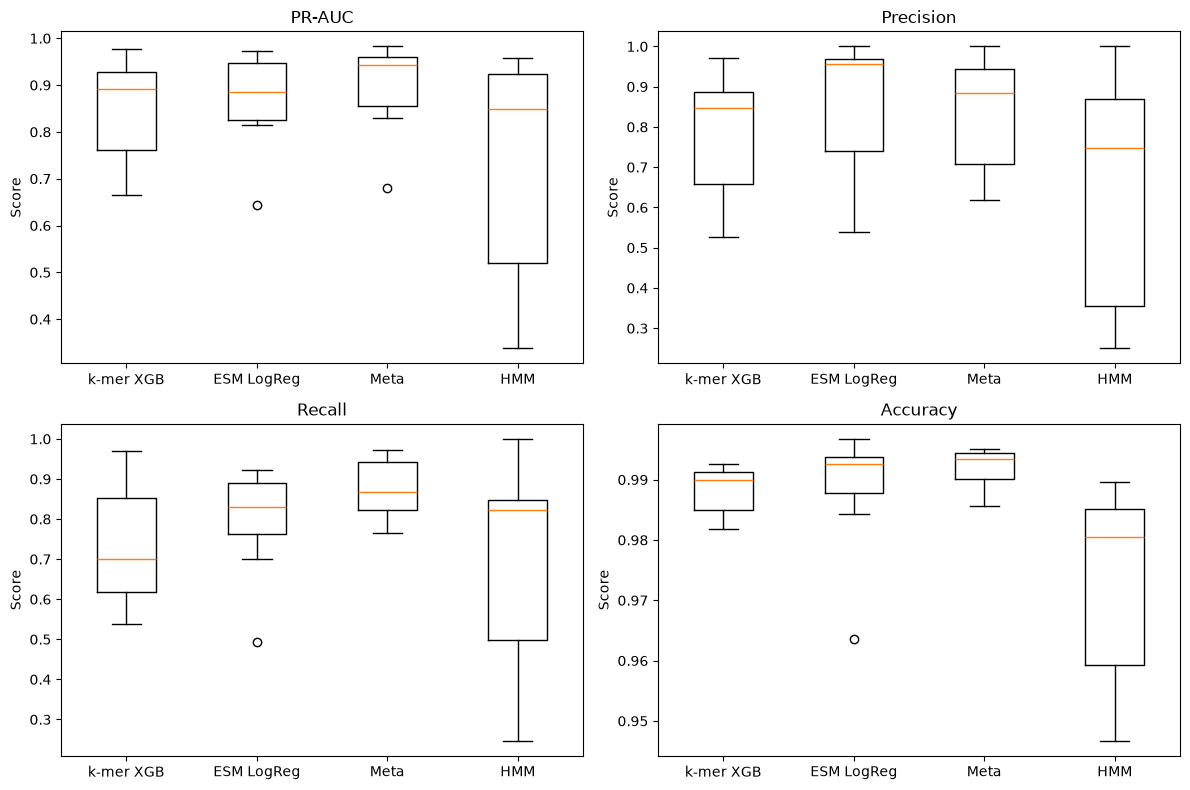

In [170]:
models = {
    'k-mer XGB': xgb_evaluator,
    'ESM LogReg': logreg_evaluator,
    'Meta': meta_evaluator,
}
model_labels = list(models)

precision = np.array([
    [result['test_precision'] for result in evaluator.fold_results.values()]
    for evaluator in models.values()
] + [hmm_fold_results['precision']])
recall = np.array([
    [result['test_recall'] for result in evaluator.fold_results.values()]
    for evaluator in models.values()
] + [hmm_fold_results['recall']])
accuracy = np.array([
    [result.get(
        'test_accuracy',
        accuracy_score(
            evaluator.fold_preds[species]['y_true'],
            evaluator.fold_preds[species]['preds'] >= result.get('threshold', 0.5),
        ),
    ) for species, result in evaluator.fold_results.items()]
    for evaluator in models.values()
] + [hmm_fold_results['accuracy']])
pr_auc = np.array([
    [result['test_pr_auc'] for result in evaluator.fold_results.values()]
    for evaluator in models.values()
] + [hmm_fold_results['test_pr_auc']])

metrics = {
    'PR-AUC': (pr_auc, model_labels + ['HMM']),
    'Precision': (precision, model_labels + ['HMM']),
    'Recall': (recall, model_labels + ['HMM']),
    'Accuracy': (accuracy, model_labels + ['HMM']),
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, (metric_name, (scores, labels)) in zip(axes.flat, metrics.items()):
    ax.boxplot(
        scores.T,
        tick_labels=labels
    )
    ax.set_title(metric_name)
    ax.set_ylabel('Score')
    # if metric_name != 'Accuracy':
    #     ax.set_ylim(0, 1)
    # else:
    #     ax.set_ylim(0.9, 1)

plt.tight_layout()
plt.show()

### Friedman & Nemenyi

https://www.jmlr.org/papers/volume7/demsar06a/demsar06a.pdf

PR-AUC: Friedman chi2=9.171, p=0.0271
Accuracy: Friedman chi2=15.261, p=0.001607
Precision: Friedman chi2=7.800, p=0.05033
  Omnibus test is not significant.
Recall: Friedman chi2=2.500, p=0.4753
  Omnibus test is not significant.


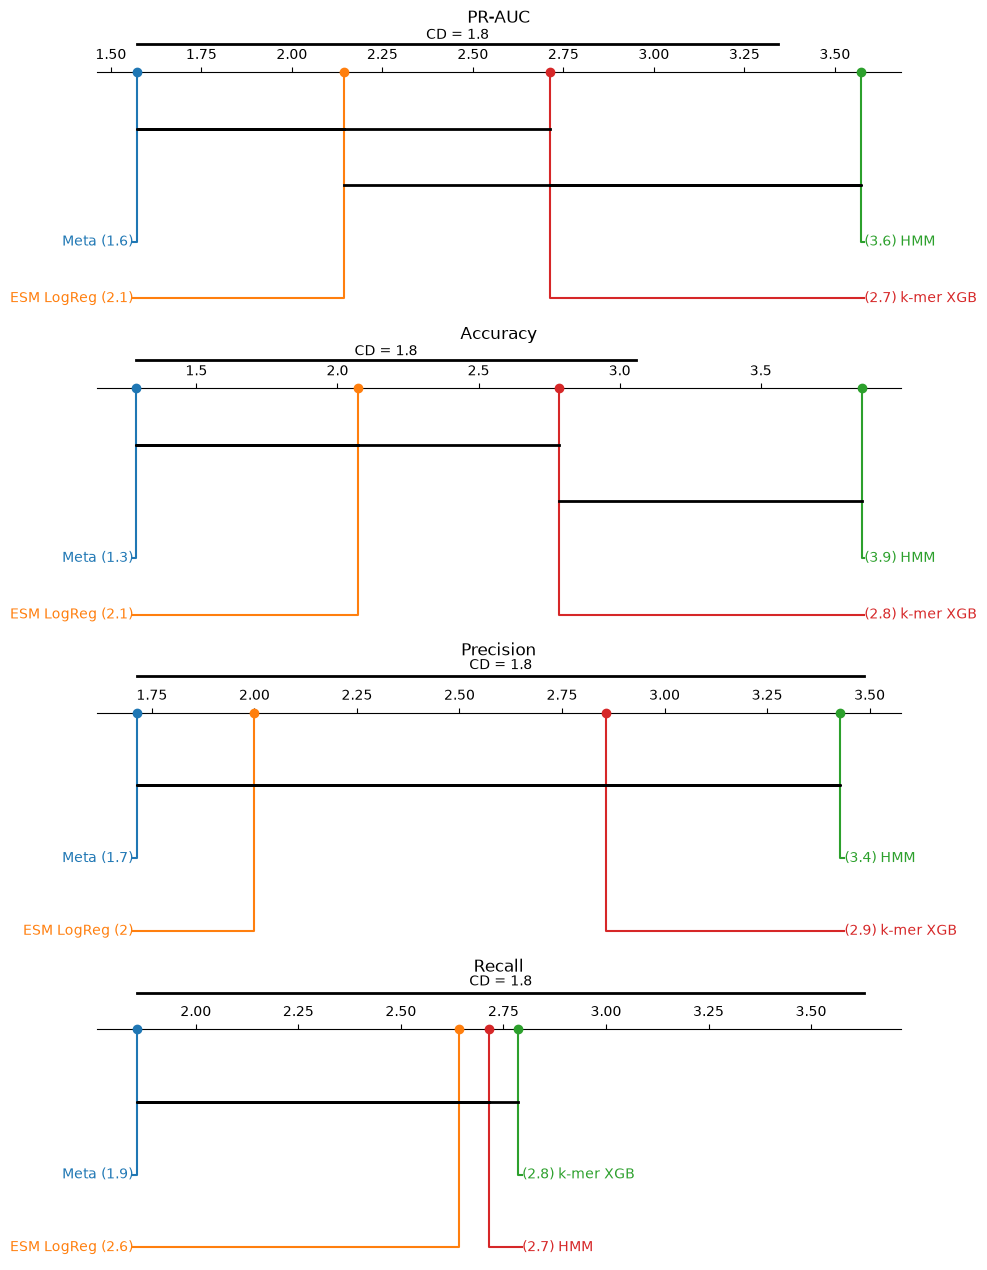

,n_folds,chi2,p_value,significant_at_0.05,best_average_rank
metric,,,,,
PR-AUC,7,9.1714,0.0271,True,Meta
Accuracy,7,15.2609,0.0016,True,Meta
Precision,7,7.8000,0.0503,False,Meta
Recall,7,2.5000,0.4753,False,Meta


In [171]:
ALPHA = 0.05
METHODS = list(models.keys()) + ['HMM']

def _species_key(name):
    return str(name).split('_')[0]

def _test_metric(evaluator, species, result, metric):
    if metric in result:
        return result[metric]
    values = evaluator.fold_preds[species]
    y_true = values['y_true']
    preds = values['preds']
    hard = preds >= result.get('threshold', 0.5)
    if metric == 'test_pr_auc':
        return average_precision_score(y_true, preds)
    if metric == 'test_precision':
        return precision_score(y_true, hard, zero_division=0)
    if metric == 'test_recall':
        return recall_score(y_true, hard, zero_division=0)
    if metric == 'test_accuracy':
        return accuracy_score(y_true, hard)
    raise KeyError(metric)

fold_species = [_species_key(name) for name in models[METHODS[0]].fold_results.keys()]
hmm_species = hmm_fold_results['species'].astype(str).tolist()
if set(fold_species) != set(hmm_species):
    raise ValueError(f'Fold mismatch between ML models and HMM baseline: {fold_species} vs {hmm_species}')

metric_columns = {
    'PR-AUC': ('test_pr_auc', 'test_pr_auc'),
    'Accuracy': ('test_accuracy', 'accuracy'),
    'Precision': ('test_precision', 'precision'),
    'Recall': ('test_recall', 'recall'),
}
scores_by_metric = {}
for metric_name, (result_key, hmm_key) in metric_columns.items():
    score_frame = pd.DataFrame({
        method: {
            _species_key(species): float(_test_metric(evaluator, species, result, result_key))
            for species, result in evaluator.fold_results.items()
        }
        for method, evaluator in models.items()
    })
    hmm_values = hmm_fold_results.set_index('species')[hmm_key].astype(float)
    score_frame['HMM'] = hmm_values.reindex(score_frame.index)
    score_frame = score_frame.reindex(columns=METHODS)
    if score_frame.isna().any().any():
        raise ValueError(f'Missing {metric_name} scores after fold alignment')
    scores_by_metric[metric_name] = score_frame

friedman_summary = []
nemenyi_results = {}
cd_values = {}

fig, axes = plt.subplots(len(scores_by_metric), 1, figsize=(10, 3.2 * len(scores_by_metric)))
if len(scores_by_metric) == 1:
    axes = [axes]

for ax, (metric_name, score_frame) in zip(axes, scores_by_metric.items()):
    statistic, p_value = friedmanchisquare(*[score_frame[method] for method in METHODS])
    ranks = score_frame.rank(axis=1, ascending=False, method='average')
    rank_means = ranks.mean(axis=0)
    nemenyi_pvalues = sp.posthoc_nemenyi_friedman(-score_frame)
    nemenyi_pvalues = nemenyi_pvalues.reindex(index=METHODS, columns=METHODS)
    n_blocks, n_methods = ranks.shape
    cd = studentized_range.ppf(1 - ALPHA, n_methods, np.inf) / np.sqrt(2) * np.sqrt(
        n_methods * (n_methods + 1) / (6 * n_blocks)
    )
    friedman_summary.append({
        'metric': metric_name,
        'n_folds': n_blocks,
        'chi2': statistic,
        'p_value': p_value,
        'significant_at_0.05': p_value < ALPHA,
        'best_average_rank': rank_means.idxmin(),
    })
    cd_values[metric_name] = cd
    nemenyi_results[metric_name] = nemenyi_pvalues if p_value < ALPHA else None
    if p_value < ALPHA:
        print(f'{metric_name}: Friedman chi2={statistic:.3f}, p={p_value:.4g}')
    else:
        print(f'{metric_name}: Friedman chi2={statistic:.3f}, p={p_value:.4g}')
        print('  Omnibus test is not significant.')

    sp.critical_difference_diagram(
        rank_means,
        nemenyi_pvalues,
        cd=cd,
        alpha=ALPHA,
        ax=ax,
        label_props={'fontsize': 10},
    )
    ax.set_title(metric_name)

plt.tight_layout()
plt.show()

friedman_summary_df = pd.DataFrame(friedman_summary).set_index('metric')
display(friedman_summary_df.round(4))

## Complete results

### Metrics

In [172]:
model_results = {
    'HMM baseline': hmm_fold_results,
    'XGB k-mer': xgb_evaluator.results_df,
    'LogReg ESM': logreg_evaluator.results_df,
    'Meta': meta_evaluator.results_df
}

pr_auc_df = pd.DataFrame([{
    'model': k,
    'pr_auc_mean': v['test_pr_auc'].mean(),
    'pr_auc_min': v['test_pr_auc'].min(),
    'pr_auc_max': v['test_pr_auc'].max(),
    'pr_auc_worst': v.loc[v['test_pr_auc'].idxmin(), 'species'],
} for k, v in model_results.items()])
display(pr_auc_df)

precision_df = pd.DataFrame([{
    'model': k,
    'precision_mean': v['test_precision'].mean(),
    'precision_min': v['test_precision'].min(),
    'precision_max': v['test_precision'].max(),
    'precision_worst': v.loc[v['test_precision'].idxmin(), 'species'],
} for k, v in model_results.items()])
display(precision_df)

recall_df = pd.DataFrame([{
    'model': k,
    'recall_mean': v['test_recall'].mean(),
    'recall_min': v['test_recall'].min(),
    'recall_max': v['test_recall'].max(),
    'recall_worst': v.loc[v['test_recall'].idxmin(), 'species'],
} for k, v in model_results.items()])
display(recall_df)

,model,pr_auc_mean,pr_auc_min,pr_auc_max,pr_auc_worst
0,HMM baseline,0.718797,0.337653,0.957323,Slycopersicum
1,XGB k-mer,0.845214,0.665361,0.978118,Slycopersicum
2,LogReg ESM,0.863608,0.642995,0.973351,Slycopersicum
3,Meta,0.890889,0.679976,0.982622,Slycopersicum


,model,precision_mean,precision_min,precision_max,precision_worst
0,HMM baseline,0.634856,0.250000,1.000000,Fvesca
1,XGB k-mer,0.776405,0.526316,0.970588,Slycopersicum
2,LogReg ESM,0.844492,0.538462,1.000000,Slycopersicum
3,Meta,0.829443,0.619048,1.000000,Slycopersicum


,model,recall_mean,recall_min,recall_max,recall_worst
0,HMM baseline,0.679978,0.246575,1.000000,Pvulgaris
1,XGB k-mer,0.735483,0.538462,0.970588,Athaliana
2,LogReg ESM,0.792588,0.493151,0.923077,Vvinifera
3,Meta,0.876392,0.764706,0.972603,Slycopersicum


### Thresholds/e-values

In [173]:
print('Note: threshold for HMM baseline is e-value. Thresholds maximize f1 per LOGO fold.')
threshold_df = pd.DataFrame([{
    'model': k,
    'threshold_mean': v['threshold'].mean(),
    'threshold_min': v['threshold'].min(),
    'min_species': v.loc[v['threshold'].idxmin(), 'species'],
    'threshold_max': v['threshold'].max(),
    'max_species': v.loc[v['threshold'].idxmax(), 'species'],
} for k, v in model_results.items()])
threshold_df

Note: threshold for HMM baseline is e-value. Thresholds maximize f1 per LOGO fold.


,model,threshold_mean,threshold_min,min_species,threshold_max,max_species
0,HMM baseline,1.609319e-122,1.248097e-207,Pvulgaris,1.126523e-121,Athaliana
1,XGB k-mer,4.314845e-01,1.413210e-01,Gmax,7.853209e-01,Vvinifera
2,LogReg ESM,8.716543e-01,7.148948e-01,Slycopersicum,9.988617e-01,Vvinifera
3,Meta,9.126327e-01,7.658630e-01,Fvesca,9.830039e-01,Vvinifera


### Counts

In [174]:
counts_df = pd.DataFrame([{
    'model': k,
    'positive': v['n_pos'].sum(),
    'found': v['found'].sum(),
    'false_positives': v['false_positives'].sum(),
} for k, v in model_results.items()])
counts_df

,model,positive,found,false_positives
0,HMM baseline,359,232,102
1,XGB k-mer,359,298,46
2,LogReg ESM,359,267,31
3,Meta,359,326,38


## Failure analysis

In [175]:
def get_miss_fp_sets(evaluator):
    misses, fps = set(), set()
    for species, details in evaluator.fold_details.items():
        threshold = evaluator.fold_results[species]['threshold']
        pred_pos = details['pred'] >= threshold
        misses.update(details[(details['y_true'] == 1) & ~pred_pos]['id'])
        fps.update(details[(details['y_true'] == 0) & pred_pos]['id'])
    return misses, fps

all_evaluators = {
    'lr_esm': logreg_evaluator,
    'xgb_kmer': xgb_evaluator,
    'meta': meta_evaluator,
}

miss_sets = {}
fp_sets = {}
for name, ev in all_evaluators.items():
    m, f = get_miss_fp_sets(ev)
    miss_sets[name] = m
    fp_sets[name] = f

miss_counter = Counter()
for s in miss_sets.values():
    miss_counter.update(s)

fp_counter = Counter()
for s in fp_sets.values():
    fp_counter.update(s)

n_models = len(all_evaluators)
print(f"Misses by agreement level (out of {n_models} models):")
print(pd.Series(miss_counter.values()).value_counts().sort_index())
print(f"\nFPs by agreement level (out of {n_models} models):")
print(pd.Series(fp_counter.values()).value_counts().sort_index())

# majority (2 of 3) as "hard" cases
majority_misses = {k for k,v in miss_counter.items() if v >= 2}
majority_fps = {k for k,v in fp_counter.items() if v >= 2}
print(f"\nMajority (2+/3) misses: {len(majority_misses)}")
print(f"Majority (2+/3) FPs: {len(majority_fps)}")

xgb_pooled_probs = pd.concat(xgb_evaluator.fold_details.values()).set_index('id')
uncertain = xgb_pooled_probs[(xgb_pooled_probs['pred'] > 0.35) & (xgb_pooled_probs['pred'] < 0.65)]
print(f"{len(uncertain)} examples XGB is uncertain about")

Misses by agreement level (out of 3 models):
1    95
2    29
Name: count, dtype: int64

FPs by agreement level (out of 3 models):
1    49
2    14
Name: count, dtype: int64

Majority (2+/3) misses: 29
Majority (2+/3) FPs: 14
35 examples XGB is uncertain about


In [176]:
species_lookup = df_kmer.set_index('gene')['species']

miss_species = species_lookup.reindex(list(majority_misses)).value_counts()
fp_species = species_lookup.reindex(list(majority_fps)).value_counts()

y_lookup = df_kmer.set_index('gene')['label']
n_pos_by_species = y_lookup[y_lookup].groupby(species_lookup).size()

error_species_df = pd.DataFrame({
    'misses': miss_species,
    'fps': fp_species,
    'n_pos': n_pos_by_species,
}).fillna(0).astype(int)

error_species_df['total_errors'] = error_species_df['misses'] + error_species_df['fps']
error_species_df['error_rate'] = error_species_df['total_errors'] / error_species_df['n_pos']

error_species_df = error_species_df[['total_errors', 'misses', 'fps', 'n_pos', 'error_rate']] \
    .sort_values('error_rate', ascending=False)

print(error_species_df)

                                                    total_errors  misses  fps  \
species                                                                         
Slycopersicum_796_ITAG5.0.protein_primaryTransc...            11       3    8   
Fvesca_226_v1.1.protein_primaryTranscriptOnly                  2       2    0   
Athaliana_447_Araport11.protein_primaryTranscri...             2       1    1   
Osativa_204_v7.0.protein_primaryTranscriptOnly                 6       6    0   
Gmax_189_protein_primaryTranscriptOnly                         9       8    1   
Vvinifera_457_v2.1.protein_primaryTranscriptOnly               9       7    2   
Pvulgaris_442_v2.1.protein_primaryTranscriptOnly               4       2    2   

                                                    n_pos  error_rate  
species                                                                
Slycopersicum_796_ITAG5.0.protein_primaryTransc...     17    0.647059  
Fvesca_226_v1.1.protein_primaryTranscriptOnly         

### Score distribution

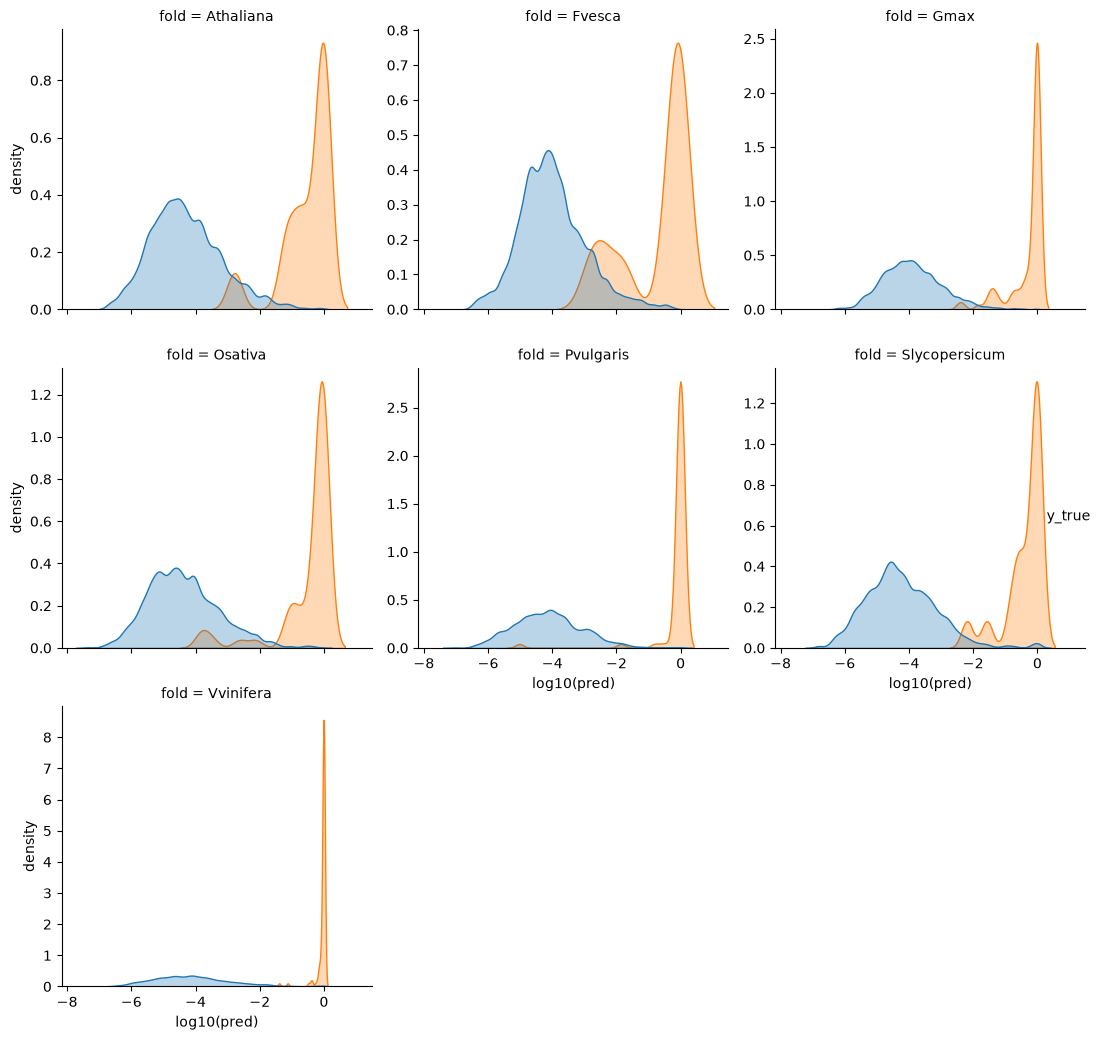

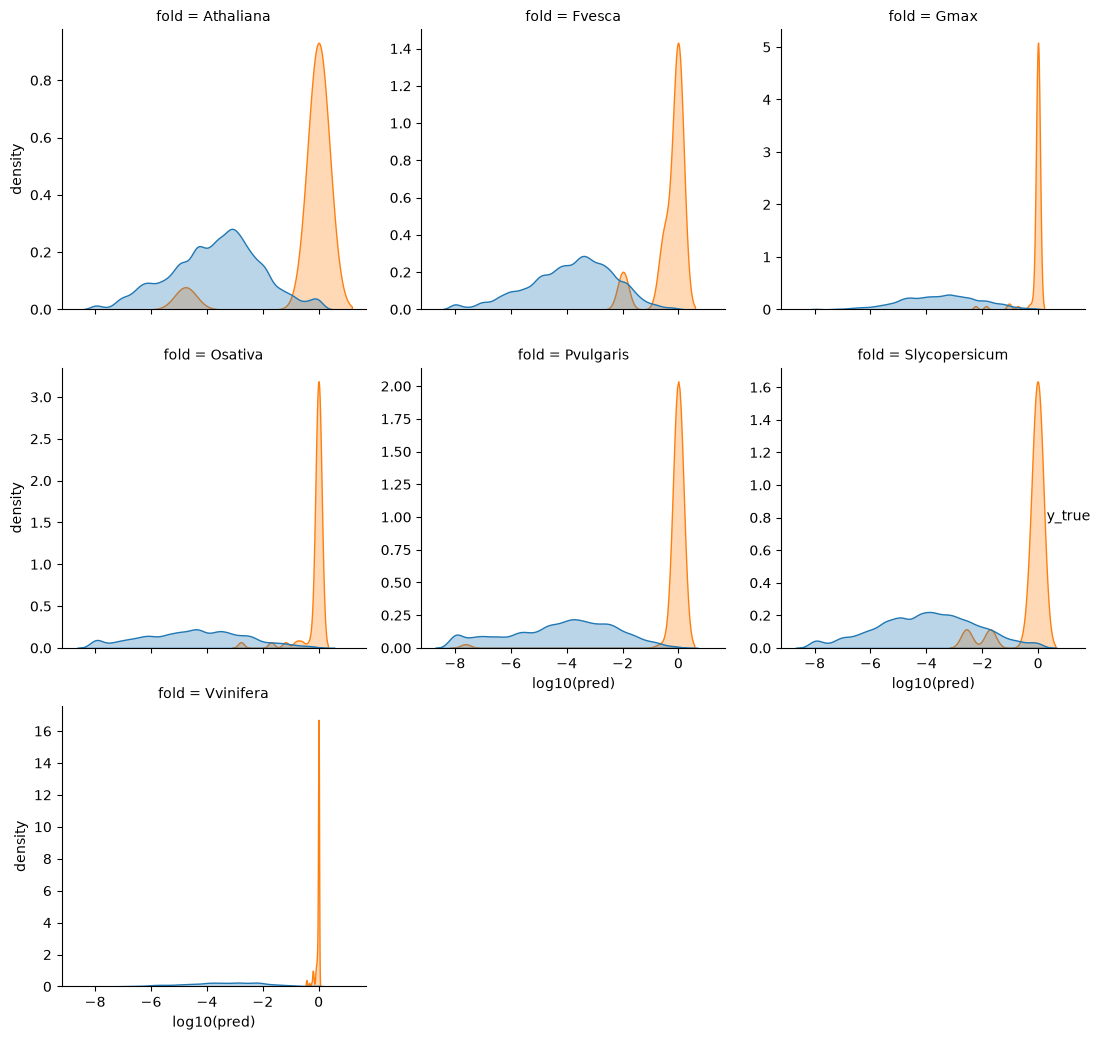

In [177]:
def plot_fold_score_kde(fold_details, eps=1e-8, bw_adjust=0.5):
    # combine all folds into one long dataframe with a fold label
    dfs = []
    for fold_name, df in fold_details.items():
        d = df[['y_true', 'pred']].copy()
        d['fold'] = str(fold_name.split('_')[0])
        dfs.append(d)
    all_df = pd.concat(dfs, ignore_index=True)

    all_df['log_pred'] = np.log10(all_df['pred'].clip(lower=eps))

    g = sns.FacetGrid(all_df, col='fold', col_wrap=3, height=3.5, sharex=True, sharey=False)
    g.map_dataframe(
        sns.kdeplot, x='log_pred', hue='y_true',
        common_norm=False, fill=True, alpha=0.3, bw_adjust=bw_adjust
    )
    g.add_legend(title='y_true')
    g.set_axis_labels('log10(pred)', 'density')
    plt.tight_layout()
    return g

g = plot_fold_score_kde(xgb_evaluator.fold_details)
plt.show()
g = plot_fold_score_kde(logreg_evaluator.fold_details)
plt.show()

### Error overlap

In [178]:
def collect_error_sets(evaluator):
    false_positives, false_negatives = set(), set()

    if evaluator.fold_details:
        fold_rows = (
            (species, details['id'], details['y_true'], details['pred'])
            for species, details in evaluator.fold_details.items()
        )
    else:
        fold_rows = (
            (
                species,
                evaluator.X.index[evaluator.groups == species],
                predictions['y_true'],
                predictions['preds'],
            )
            for species, predictions in evaluator.fold_preds.items()
        )

    for species, ids, y_true, predictions in fold_rows:
        threshold = evaluator.fold_results[species]['threshold']
        predicted_positive = predictions >= threshold
        false_positives.update(ids[(y_true == 0) & predicted_positive])
        false_negatives.update(ids[(y_true == 1) & ~predicted_positive])

    return {
        'false_positives': false_positives,
        'false_negatives': false_negatives,
    }


def collect_hmm_error_sets(hmm_results):
    test_results = hmm_results[hmm_results['split'] == 'test']
    return {
        'false_positives': set(test_results.loc[
            (test_results['true_label'] == 0) & (test_results['pred_label'] == 1),
            'record_id',
        ]),
        'false_negatives': set(test_results.loc[
            (test_results['true_label'] == 1) & (test_results['pred_label'] == 0),
            'record_id',
        ]),
    }


error_sets = {
    'k-mer XGB': collect_error_sets(xgb_evaluator),
    'ESM LogReg': collect_error_sets(logreg_evaluator),
    'Meta': collect_error_sets(meta_evaluator),
    'HMM': collect_hmm_error_sets(hmm_results_df),
}


def error_overlap_table(error_sets, error_type):
    rows = []
    names = list(error_sets)
    for i, model_a in enumerate(names):
        for model_b in names[i + 1:]:
            errors_a = error_sets[model_a][error_type]
            errors_b = error_sets[model_b][error_type]
            union = errors_a | errors_b
            intersection = errors_a & errors_b
            rows.append({
                'model_a': model_a,
                'model_b': model_b,
                'errors_a': len(errors_a),
                'errors_b': len(errors_b),
                'overlap': len(intersection),
                'jaccard': len(intersection) / len(union) if union else 1.0,
                'only_a': len(errors_a - errors_b),
                'only_b': len(errors_b - errors_a),
            })
    return pd.DataFrame(rows)


for error_type, label in [('false_positives', 'false positives'), ('false_negatives', 'false negatives')]:
    print(f'\n{label.title()} by model:')
    print(pd.Series({model: len(errors[error_type]) for model, errors in error_sets.items()}))
    display(error_overlap_table(error_sets, error_type).sort_values('jaccard', ascending=False))


for error_type, label in [('false_positives', 'false positives'), ('false_negatives', 'false negatives')]:
    all_errors = set.union(*(errors[error_type] for errors in error_sets.values()))
    agreement = Counter(
        sum(protein in errors[error_type] for errors in error_sets.values())
        for protein in all_errors
    )
    print(f'\n{label.title()} agreement across models:')
    print(pd.Series(agreement).sort_index().rename('n_proteins').rename_axis('n_models'))


common_false_positives = set.intersection(*(errors['false_positives'] for errors in error_sets.values()))
common_false_negatives = set.intersection(*(errors['false_negatives'] for errors in error_sets.values()))
print(f'\nFalse positives shared by all four methods ({len(common_false_positives)}): {sorted(common_false_positives)}')
print(f'False negatives shared by all four methods ({len(common_false_negatives)}): {sorted(common_false_negatives)}')


False Positives by model:
k-mer XGB      46
ESM LogReg     31
Meta           38
HMM           102
dtype: int64


,model_a,model_b,errors_a,errors_b,overlap,jaccard,only_a,only_b
1,k-mer XGB,Meta,46,38,31,0.584906,15,7
3,ESM LogReg,Meta,31,38,19,0.380000,12,19
0,k-mer XGB,ESM LogReg,46,31,14,0.222222,32,17
4,ESM LogReg,HMM,31,102,13,0.108333,18,89
5,Meta,HMM,38,102,13,0.102362,25,89
2,k-mer XGB,HMM,46,102,10,0.072464,36,92



False Negatives by model:
k-mer XGB      61
ESM LogReg     92
Meta           33
HMM           127
dtype: int64


,model_a,model_b,errors_a,errors_b,overlap,jaccard,only_a,only_b
1,k-mer XGB,Meta,61,33,30,0.468750,31,3
4,ESM LogReg,HMM,92,127,63,0.403846,29,64
3,ESM LogReg,Meta,92,33,28,0.288660,64,5
0,k-mer XGB,ESM LogReg,61,92,29,0.233871,32,63
2,k-mer XGB,HMM,61,127,27,0.167702,34,100
5,Meta,HMM,33,127,20,0.142857,13,107



False Positives agreement across models:
n_models
1    109
2     22
3     12
4      7
Name: n_proteins, dtype: int64

False Negatives agreement across models:
n_models
1    93
2    53
3    18
4    15
Name: n_proteins, dtype: int64

False positives shared by all four methods (7): ['AT4G18250.1', 'Solyc01T000275.1', 'Solyc09T000267.1', 'Solyc11T000232.1', 'Solyc11T000233.1', 'Solyc12T002359.1', 'VIT_214s0006g02600.2']
False negatives shared by all four methods (15): ['Glyma02g33910.2|PACid:26287779', 'Glyma07g10751.2|PACid:26350123', 'Glyma18g40680.1|PACid:26355329', 'Glyma18g47480.2|PACid:26356692', 'LOC_Os03g12470.1', 'LOC_Os03g58750.1', 'LOC_Os05g25390.1', 'LOC_Os12g40419.1', 'Phvul.001G000500.1.p', 'Phvul.009G259800.1.p', 'Solyc01T000282.1', 'VIT_201s0011g04280.1', 'VIT_216s0148g00070.1', 'mrna18355.1-v1.0-hybrid', 'mrna20850.1-v1.0-hybrid']
